
Mean of each numerical column:
games         14.125000
att          478.406250
cmp          306.562500
comp_pct      64.296875
yds         3515.062500
ypa            7.375000
td            22.375000
int           10.343750
sack          32.312500
loss         217.093750
rating        93.387500
dtype: float64

Standard deviation of each numerical column:
games         2.406309
att         110.360366
cmp          68.929575
comp_pct      3.627537
yds         852.437489
ypa           0.796768
td            6.256609
int           5.839849
sack         10.514008
loss         70.786075
rating       11.054725
dtype: float64


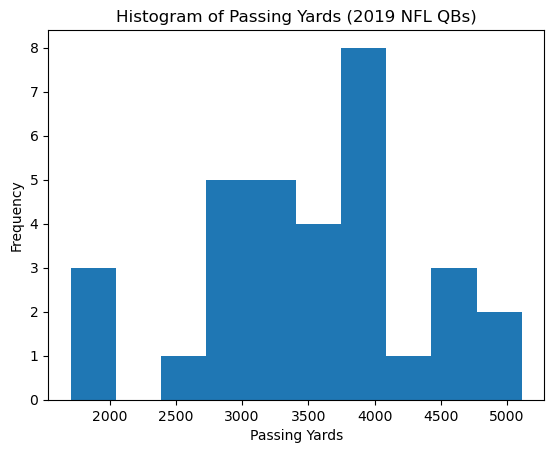

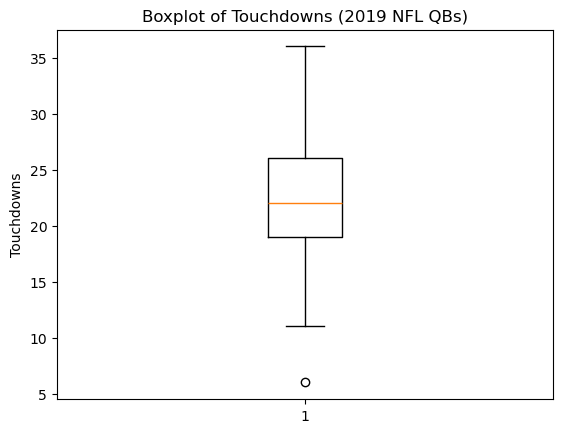


Outliers in Touchdowns:
          name  td
24  Joe Flacco   6


In [3]:
# ================================================================
# Title: 9.2 Exercise 1
# Author: jaweria-B (GitHub username)
# Date: 3/1/2026
# Modified By: Cyndie Cramer
# Description: Summarizing Data
# =================================================================

# Import the needed libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r"C:\Users\cyndi\OneDrive - Bellevue University\Data Science\qb_stats.csv"
df = pd.read_csv(file_path)


# (a) Mean of each numerical column
numerical_cols = df.select_dtypes(include='number')

means = numerical_cols.mean()
print("\nMean of each numerical column:")
print(means)

# (b) Standard deviation of each numerical column
std_devs = numerical_cols.std()
print("\nStandard deviation of each numerical column:")
print(std_devs)

# (c) Histogram of number of yards
plt.figure()
plt.hist(df["yds"], bins=10)
plt.title("Histogram of Passing Yards (2019 NFL QBs)")
plt.xlabel("Passing Yards")
plt.ylabel("Frequency")
plt.show()

# (d) Boxplot of number of touchdowns
plt.figure()
plt.boxplot(df["td"])
plt.title("Boxplot of Touchdowns (2019 NFL QBs)")
plt.ylabel("Touchdowns")
plt.show()

# Identify outliers using IQR method
Q1 = df["td"].quantile(0.25)
Q3 = df["td"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["td"] < lower_bound) | (df["td"] > upper_bound)]

print("\nOutliers in Touchdowns:")
print(outliers[["name", "td"]])

P(Brown Hair) = 0.5123456790123457
P(Blue Eyes) = 0.24691358024691357
P(Blue Eyes | Brown Hair) = 0.21686746987951808
P(Brown Hair | Blue Eyes) = 0.45
P(Brown and Blue) = 0.1111111111111111
P(Brown) * P(Blue) = 0.12650510592897424
Brown hair and blue eyes do NOT appear to be independent.


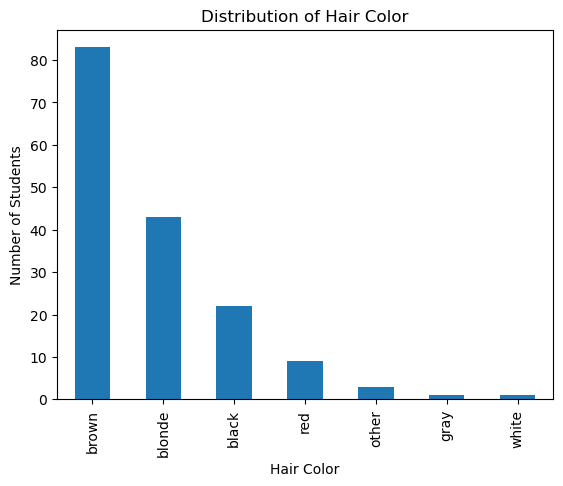

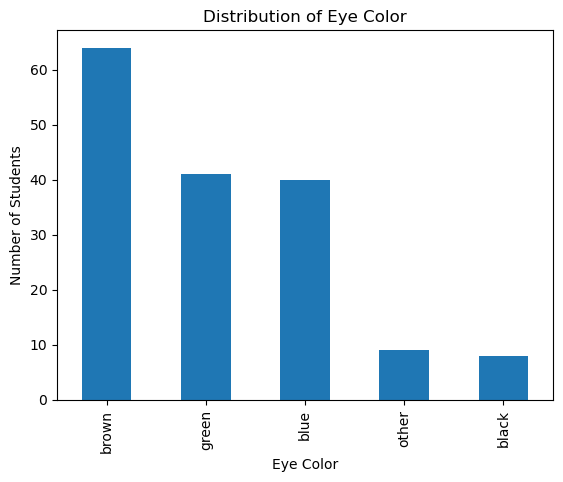

In [7]:
# ================================================================
# Title: 9.2 Exercise 2
# Author: allendowney (GitHub username)
# Date: 3/1/2026
# Modified By: Cyndie Cramer
# Description: Calculating Probabilities from Data
# =================================================================

# Import the needed libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = r"C:\Users\cyndi\OneDrive - Bellevue University\Data Science\survey_data.csv"
df = pd.read_csv(file_path)

# Data Cleaning

# Standardize formatting
df["hair_color"] = df["hair_color"].str.strip().str.lower()
df["eye_color"] = df["eye_color"].str.strip().str.lower()

# Combine blond and blonde
df["hair_color"] = df["hair_color"].replace({
    "blond": "blonde"
})

# Total students
total_students = len(df)

# (a) Probability of Brown Hair
p_brown_hair = len(df[df["hair_color"] == "brown"]) / total_students
print("P(Brown Hair) =", p_brown_hair)

# (b) Probability of Blue Eyes
p_blue_eyes = len(df[df["eye_color"] == "blue"]) / total_students
print("P(Blue Eyes) =", p_blue_eyes)

# (c) Probability of Blue Eyes and Brown Hair
brown_hair_df = df[df["hair_color"] == "brown"]
p_blue_given_brown = len(
    brown_hair_df[brown_hair_df["eye_color"] == "blue"]
) / len(brown_hair_df)

print("P(Blue Eyes | Brown Hair) =", p_blue_given_brown)

# (d) Probability of Brown Hair and Blue Eyes
blue_eyes_df = df[df["eye_color"] == "blue"]
p_brown_given_blue = len(
    blue_eyes_df[blue_eyes_df["hair_color"] == "brown"]
) / len(blue_eyes_df)

print("P(Brown Hair | Blue Eyes) =", p_brown_given_blue)

# (e) Independence Check. Two events are independent if: P(A and B) = P(A) * P(B)
p_brown_and_blue = len(
    df[(df["hair_color"] == "brown") & (df["eye_color"] == "blue")]
) / total_students

print("P(Brown and Blue) =", p_brown_and_blue)
print("P(Brown) * P(Blue) =", p_brown_hair * p_blue_eyes)

if abs(p_brown_and_blue - (p_brown_hair * p_blue_eyes)) < 0.0001:
    print("Brown hair and blue eyes appear to be independent.")
else:
    print("Brown hair and blue eyes do NOT appear to be independent.")

# (f) Bar Graphs

# Hair color
plt.figure()
df["hair_color"].value_counts().plot(kind="bar")
plt.title("Distribution of Hair Color")
plt.xlabel("Hair Color")
plt.ylabel("Number of Students")
plt.show()

# Eye color
plt.figure()
df["eye_color"].value_counts().plot(kind="bar")
plt.title("Distribution of Eye Color")
plt.xlabel("Eye Color")
plt.ylabel("Number of Students")
plt.show()